# Lab 21 - LoRA / QLoRA Fine-tuning - T4 / Free Colab Edition

**Goal:** fine-tune `unsloth/Llama-3.2-3B-Instruct-bnb-4bit` on `tatsu-lab/alpaca` with 500 cleaned samples, then compare LoRA ranks `r=8`, `r=16`, and `r=64`.

This notebook is prepared for **Option B** submission: keep the zip lightweight, push the selected adapter to Hugging Face Hub, and submit the notebook plus CSV/result files.

| Setting | Value |
|---|---|
| Base model | `unsloth/Llama-3.2-3B-Instruct-bnb-4bit` |
| Dataset | `tatsu-lab/alpaca` |
| Samples | 500 after filtering short outputs |
| GPU target | Colab T4 16 GB |
| LoRA baseline | `r=16`, `alpha=32`, target `q_proj` and `v_proj` |
| Rank experiment | `r=8`, `r=16`, `r=64` |
| Optional stretch | W&B logging + target all linear layers run |
| Submission style | Option B: GitHub + Hugging Face Hub |

Expected outputs in `OUTPUT_DIR`:

- `adapters/r8`, `adapters/r16`, `adapters/r64`
- `results/rank_experiment_summary.csv`
- `results/qualitative_comparison.csv`
- `results/loss_curve.png`
- `LINKS.md`


## 0. Setup & Environment Check

In [1]:
# Verify GPU is available before installing anything
!nvidia-smi

Thu May  7 02:50:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
assert torch.cuda.is_available(), "GPU runtime is required. In Colab: Runtime > Change runtime type > GPU"
name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {name}")
print(f"VRAM: {vram_gb:.1f} GB")
print(f"CUDA: {torch.version.cuda}")
print(f"PyTorch: {torch.__version__}")

if vram_gb < 14:
    print("Warning: this notebook is tuned for T4 16GB. Reduce batch size or max sequence length if OOM happens.")
elif "T4" not in name:
    print(f"Note: this notebook is optimized for T4. Your GPU ({name}) should still work.")

GPU: Tesla T4
VRAM: 15.6 GB
CUDA: 12.8
PyTorch: 2.10.0+cu128


In [3]:
%%capture
# Install training stack. Run this cell once, then continue without restarting unless Colab asks you to.
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "trl>=0.12,<0.16" peft accelerate bitsandbytes
!pip install -q datasets matplotlib seaborn pandas wandb huggingface_hub

In [5]:
# Global configuration
import os, gc, math, time, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
DATASET_NAME = "tatsu-lab/alpaca"
N_SAMPLES = 500
MAX_SEQ_CAP = 1024

MOUNT_DRIVE = False  # Set True if you want persistent checkpoints in Google Drive.
if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/lab21_lora_qlora'
else:
    OUTPUT_DIR = '/content/lab21_lora_qlora'

ADAPTERS_DIR = os.path.join(OUTPUT_DIR, 'adapters')
RESULTS_DIR = os.path.join(OUTPUT_DIR, 'results')
os.makedirs(ADAPTERS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Llama models can require a Hugging Face token and accepted model terms.
# Keep this True for first Colab run. You can set False after the token is cached.
LOGIN_TO_HF = True
if LOGIN_TO_HF:
    from huggingface_hub import notebook_login
    notebook_login()

# W&B is optional but recommended for bonus tracking and loss curves.
USE_WANDB = True
WANDB_PROJECT = 'lab21-lora-qlora'
WANDB_REPORT_TO = 'none'
if USE_WANDB:
    import wandb
    wandb.login()
    os.environ['WANDB_PROJECT'] = WANDB_PROJECT
    WANDB_REPORT_TO = 'wandb'

print(f"Output dir: {OUTPUT_DIR}")
print(f"Adapters dir: {ADAPTERS_DIR}")
print(f"Results dir: {RESULTS_DIR}")
print(f"W&B logging: {WANDB_REPORT_TO}")

Output dir: /content/lab21_lora_qlora
Adapters dir: /content/lab21_lora_qlora/adapters
Results dir: /content/lab21_lora_qlora/results
W&B logging: wandb


## 1. Dataset Preparation

The rubric requires Alpaca-format data, cleaning, token length analysis, and a 90/10 split. This section loads `tatsu-lab/alpaca`, filters short outputs, deduplicates rows, and samples 500 examples with seed 42.

In [6]:
from datasets import load_dataset, Dataset

raw_full = load_dataset(DATASET_NAME, split='train')
print(f"Loaded full dataset: {len(raw_full):,} rows")
print(f"Columns: {raw_full.column_names}")

required_cols = ['instruction', 'input', 'output']
df = raw_full.to_pandas()[required_cols].fillna('')
for col in required_cols:
    df[col] = df[col].astype(str).str.strip()

before = len(df)
df = df[(df['instruction'] != '') & (df['output'] != '')].copy()
df['output_token_count_rough'] = df['output'].str.split().str.len()
df = df[df['output_token_count_rough'] >= 10].copy()
df = df.drop_duplicates(subset=required_cols).reset_index(drop=True)

after_clean = len(df)
sample_n = min(N_SAMPLES, after_clean)
df = df.sample(n=sample_n, random_state=SEED).reset_index(drop=True)
raw = Dataset.from_pandas(df[required_cols], preserve_index=False)

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning/dedup: {after_clean:,}")
print(f"Selected samples: {len(raw):,}")
print("\nSample row:")
print(raw[0])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Loaded full dataset: 52,002 rows
Columns: ['instruction', 'input', 'output', 'text']
Rows before cleaning: 52,002
Rows after cleaning/dedup: 38,571
Selected samples: 500

Sample row:
{'instruction': "Create a design and layout for a children's bedroom.", 'input': '', 'output': 'The bedroom should be bright, cheerful and inviting, with vibrant colors and patterns throughout. The walls should be painted a light, sunny yellow and decorated with pictures, posters and art work. The bed should be cozy and comfortable, with soft bedding and lots of pillows. The furniture should include a desk and chair for studying, a toy chest and shelves to store items, and a comfy armchair for reading. A set of lamps of various sizes, shapes and colors should also be included to provide warm lighting in the room. Lastly, an inspiring rug should be placed in the center of the room, to add a pop of color and warmth to the space.'}


In [7]:
# Convert to Alpaca instruction format for SFTTrainer.
ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def format_alpaca(example):
    instruction = (example.get('instruction') or '').strip()
    inp = (example.get('input') or '').strip()
    output = (example.get('output') or '').strip()
    if inp:
        text = ALPACA_TEMPLATE.format(instruction=instruction, input=inp, output=output)
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=instruction, output=output)
    return {'text': text}

ds = raw.map(format_alpaca, remove_columns=raw.column_names)
print(ds[0]['text'][:700])

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

### Instruction:
Create a design and layout for a children's bedroom.

### Response:
The bedroom should be bright, cheerful and inviting, with vibrant colors and patterns throughout. The walls should be painted a light, sunny yellow and decorated with pictures, posters and art work. The bed should be cozy and comfortable, with soft bedding and lots of pillows. The furniture should include a desk and chair for studying, a toy chest and shelves to store items, and a comfy armchair for reading. A set of lamps of various sizes, shapes and colors should also be included to provide warm lighting in the room. Lastly, an inspiring rug should be placed in the center of the room, to add a pop of color


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Token length distribution:
  min=29, max=665
  p50=87, p95=179, p99=296
Chosen max_seq_length = 256 (cap=1024)


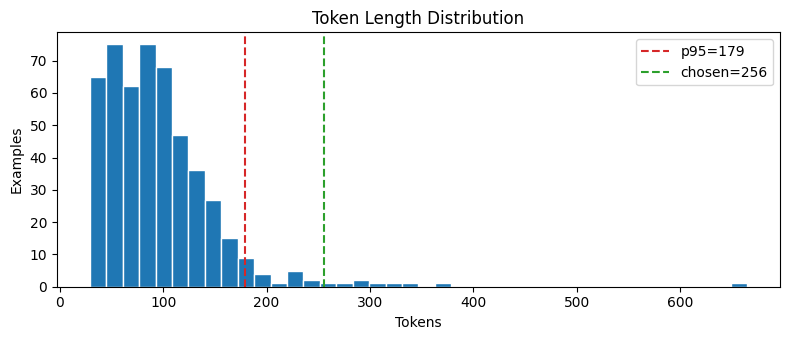

In [8]:
# Token length analysis -> p95 -> round up to power of two, capped for T4.
from transformers import AutoTokenizer

analysis_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(analysis_tokenizer.encode(row['text'])) for row in ds]

p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))
MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256) - 1).bit_length())

print('Token length distribution:')
print(f"  min={min(lengths)}, max={max(lengths)}")
print(f"  p50={p50}, p95={p95}, p99={p99}")
print(f"Chosen max_seq_length = {MAX_SEQ_LENGTH} (cap={MAX_SEQ_CAP})")

plt.figure(figsize=(8, 3.5))
plt.hist(lengths, bins=40, color='#1f77b4', edgecolor='white')
plt.axvline(p95, color='#d62728', linestyle='--', label=f'p95={p95}')
plt.axvline(MAX_SEQ_LENGTH, color='#2ca02c', linestyle='--', label=f'chosen={MAX_SEQ_LENGTH}')
plt.xlabel('Tokens')
plt.ylabel('Examples')
plt.title('Token Length Distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# 90/10 train/eval split.
split = ds.train_test_split(test_size=0.1, seed=SEED)
train_ds = split['train']
eval_ds = split['test']
print(f"Train: {len(train_ds)} | Eval: {len(eval_ds)}")

Train: 450 | Eval: 50


## 2. Load Model + Configure LoRA

Baseline follows the lab spec: `r=16`, `alpha=32`, `target_modules=["q_proj", "v_proj"]`, `lora_dropout=0`, and Unsloth gradient checkpointing.

In [10]:
from unsloth import FastLanguageModel

Q_V_MODULES = ['q_proj', 'v_proj']
ALL_LINEAR_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']

def load_base_model():
    """Reload the 4-bit base model. Call once per experiment to start from the same weights."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=True,
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return model, tokenizer

def wrap_with_lora(model, r, alpha, target_modules=None):
    """Attach a LoRA adapter to the base model."""
    if target_modules is None:
        target_modules = Q_V_MODULES
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=target_modules,
        lora_dropout=0,
        bias='none',
        use_gradient_checkpointing='unsloth',
        random_state=SEED,
    )

def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

base_model, tokenizer = load_base_model()
model = wrap_with_lora(base_model, r=16, alpha=32)
trainable_16, total_16 = count_trainable_params(model)
print(f"Trainable r=16: {trainable_16:,} ({100 * trainable_16 / total_16:.4f}% of {total_16:,})")

/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:127: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch Attention layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.5.2 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable r=16: 4,587,520 (0.2537% of 1,808,051,200)


## 3. Trainer Utilities

T4 mode disables evaluation during training and evaluates manually after each run to reduce OOM risk.

In [11]:
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect, trl, transformers

print(f"trl: {trl.__version__} | transformers: {transformers.__version__}")

# Compatibility shim for old TRL + new Transformers combinations.
try:
    import unsloth.models._utils as _u_utils
    _underlying_init = getattr(_u_utils, '_original_trainer_init', Trainer.__init__)
    if not getattr(_underlying_init, '_aliased', False):
        def _aliased_trainer_init(self, *args, **kwargs):
            if 'tokenizer' in kwargs and 'processing_class' not in kwargs:
                kwargs['processing_class'] = kwargs.pop('tokenizer')
            return _underlying_init(self, *args, **kwargs)
        _aliased_trainer_init._aliased = True
        _u_utils._original_trainer_init = _aliased_trainer_init
        if 'tokenizer' not in inspect.signature(Trainer.__init__).parameters:
            _orig_t = Trainer.__init__
            def _t_init(self, *args, **kwargs):
                if 'tokenizer' in kwargs and 'processing_class' not in kwargs:
                    kwargs['processing_class'] = kwargs.pop('tokenizer')
                return _orig_t(self, *args, **kwargs)
            _t_init._aliased = True
            Trainer.__init__ = _t_init
        print('Trainer.__init__ compatibility patch applied')
except Exception as patch_error:
    print(f"Compatibility patch skipped: {patch_error}")

try:
    from trl import SFTConfig
    _HAS_SFTCONFIG = True
except ImportError:
    _HAS_SFTCONFIG = False

_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY = 'eval_strategy' if 'eval_strategy' in _TA_PARAMS else 'evaluation_strategy'
_SFT_PARAMS = inspect.signature(SFTTrainer.__init__).parameters
_SUPPORTS_OLD_KWARGS = 'dataset_text_field' in _SFT_PARAMS

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir, **overrides):
    base_kwargs = dict(
        output_dir=os.path.join(OUTPUT_DIR, output_subdir),
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        eval_accumulation_steps=4,
        prediction_loss_only=True,
        gradient_accumulation_steps=8,
        warmup_ratio=0.10,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type='cosine',
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=5,
        save_strategy='epoch',
        optim='adamw_8bit',
        weight_decay=0.01,
        seed=SEED,
        report_to=WANDB_REPORT_TO,
        run_name=f"lab21-{output_subdir}",
    )
    base_kwargs[_EVAL_KEY] = 'no'
    base_kwargs.update(overrides)

    if _HAS_SFTCONFIG:
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        sft_extra = dict(dataset_text_field='text', packing=False, max_seq_length=MAX_SEQ_LENGTH)
        sft_extra = {k: v for k, v in sft_extra.items() if k in sft_params}
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        args = SFTConfig(**valid_base, **sft_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        'model': model,
        'train_dataset': train_ds,
        'eval_dataset': eval_ds,
        'args': args,
    }
    if 'processing_class' in _SFT_PARAMS:
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer
    if _SUPPORTS_OLD_KWARGS:
        trainer_kwargs.update(dict(dataset_text_field='text', max_seq_length=MAX_SEQ_LENGTH, packing=False))
    return SFTTrainer(**trainer_kwargs)

def safe_evaluate(trainer):
    """Robust eval path for T4: standard evaluate first, manual loss loop if needed."""
    gc.collect()
    torch.cuda.empty_cache()

    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    try:
        return trainer.evaluate()['eval_loss']
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        print(f"trainer.evaluate() failed ({type(e).__name__}). Falling back to manual eval.")

    gc.collect()
    torch.cuda.empty_cache()
    m = trainer.model
    m.eval()
    eval_dl = trainer.get_eval_dataloader()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in eval_dl:
            batch = {k: v.to(m.device) for k, v in batch.items() if hasattr(v, 'to')}
            out = m(**batch)
            total += out.loss.item()
            n += 1
            del out
            torch.cuda.empty_cache()
    return total / max(n, 1)

trl: 0.15.2 | transformers: 5.5.0
Trainer.__init__ compatibility patch applied


In [13]:
# Evaluate the frozen base model for the quantitative comparison table.
# Transformers 5.x refuses to build Trainer on a purely quantized non-PEFT model,
# so base eval uses a manual loss loop instead of SFTTrainer.
def evaluate_base_model(batch_size=1):
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_eval_model, base_eval_tok = load_base_model()
    FastLanguageModel.for_inference(base_eval_model)
    base_eval_model.eval()

    losses = []
    texts = eval_ds['text']
    t0 = time.time()

    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch_texts = texts[start:start + batch_size]
            inputs = base_eval_tok(
                batch_texts,
                return_tensors='pt',
                padding=True,
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
            ).to('cuda')
            labels = inputs['input_ids'].clone()
            labels[inputs['attention_mask'] == 0] = -100
            out = base_eval_model(**inputs, labels=labels)
            losses.append(out.loss.detach().float().item())
            del inputs, labels, out
            torch.cuda.empty_cache()

    wall = time.time() - t0
    eval_loss = float(np.mean(losses))
    vram = torch.cuda.max_memory_allocated() / 1e9
    metrics = {
        'run': 'base',
        'rank': 0,
        'alpha': 0,
        'target_modules': 'none',
        'trainable_params': 0,
        'train_time_min': 0.0,
        'eval_time_min': wall / 60,
        'peak_vram_gb': vram,
        'eval_loss': eval_loss,
        'eval_perplexity': float(np.exp(eval_loss)),
    }

    del base_eval_model, base_eval_tok
    gc.collect()
    torch.cuda.empty_cache()
    return metrics

base_metrics = evaluate_base_model(batch_size=1)
print(base_metrics)

==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
`use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transf

{'run': 'base', 'rank': 0, 'alpha': 0, 'target_modules': 'none', 'trainable_params': 0, 'train_time_min': 0.0, 'eval_time_min': 0.29520585934321086, 'peak_vram_gb': 6.997195264, 'eval_loss': 2.200242257118225, 'eval_perplexity': 9.027200138050128}


## 4. Train Baseline `r=16`

In [14]:
# Train baseline r=16.
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, 'r16_qv')

t0 = time.time()
result_16 = trainer_16.train()
wall_16 = time.time() - t0
vram_16 = torch.cuda.max_memory_allocated() / 1e9

adapter_16_dir = os.path.join(ADAPTERS_DIR, 'r16')
trainer_16.save_model(adapter_16_dir)
tokenizer.save_pretrained(adapter_16_dir)
print(f"r=16 adapter saved to {adapter_16_dir}")

try:
    eval_loss_16 = safe_evaluate(trainer_16)
    ppl_16 = float(np.exp(eval_loss_16))
except Exception as e:
    print(f"Eval failed: {e}. Setting NaN; rerun evaluation later if needed.")
    eval_loss_16 = float('nan')
    ppl_16 = float('nan')

baseline_metrics = {
    'run': 'r16_qv',
    'rank': 16,
    'alpha': 32,
    'target_modules': '+'.join(Q_V_MODULES),
    'trainable_params': int(trainable_16),
    'train_time_min': wall_16 / 60,
    'eval_time_min': float('nan'),
    'peak_vram_gb': vram_16,
    'eval_loss': eval_loss_16,
    'eval_perplexity': ppl_16,
}
print(baseline_metrics)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/450 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/50 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 4,587,520 of 3,217,337,344 (0.14% trained)


...

Step,Training Loss
5,2.206225
10,2.061320
15,1.837007
20,1.809214
25,1.466916
30,1.504424
35,1.696730
40,1.682086
45,1.614657
50,1.520366


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/r16_qv/checkpoint-57/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/r16_qv/checkpoint-114/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/r16_qv/checkpoint-171/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/adapters/r16/tokenizer_config.json.


r=16 adapter saved to /content/lab21_lora_qlora/adapters/r16


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

{'run': 'r16_qv', 'rank': 16, 'alpha': 32, 'target_modules': 'q_proj+v_proj', 'trainable_params': 4587520, 'train_time_min': 7.223533578713735, 'eval_time_min': nan, 'peak_vram_gb': 5.679250944, 'eval_loss': 1.5109350681304932, 'eval_perplexity': 4.530965575611295}


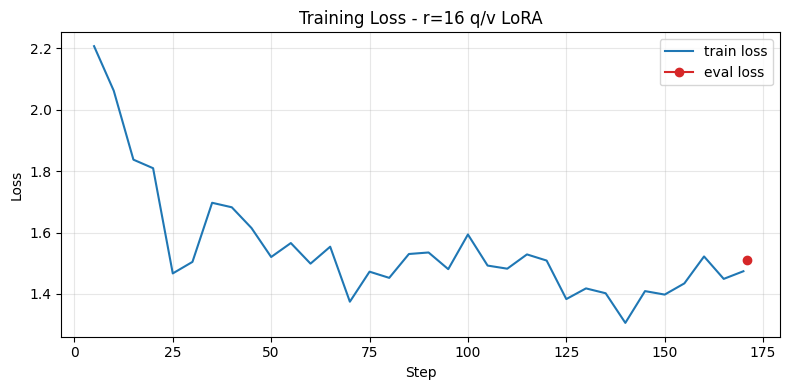

Saved loss curve to /content/lab21_lora_qlora/results/loss_curve.png
Note: mid-training eval is disabled on T4, so the plot usually contains train loss only.


In [15]:
# Plot and save the r=16 loss curve.
def plot_losses(log_history, title='Loss Curve', save_path=None):
    df = pd.DataFrame(log_history)
    train = df[df['loss'].notna()] if 'loss' in df else pd.DataFrame()
    eval_ = df[df['eval_loss'].notna()] if 'eval_loss' in df else pd.DataFrame()

    plt.figure(figsize=(8, 4))
    if not train.empty:
        plt.plot(train['step'], train['loss'], label='train loss', color='#1f77b4')
    if not eval_.empty:
        plt.plot(eval_['step'], eval_['eval_loss'], label='eval loss', color='#d62728', marker='o')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()

loss_curve_path = os.path.join(RESULTS_DIR, 'loss_curve.png')
plot_losses(trainer_16.state.log_history, title='Training Loss - r=16 q/v LoRA', save_path=loss_curve_path)
print(f"Saved loss curve to {loss_curve_path}")
print('Note: mid-training eval is disabled on T4, so the plot usually contains train loss only.')

## 5. Rank Experiment: `r=8` and `r=64`

Each run reloads the same 4-bit base model, applies a fresh LoRA adapter, trains with the same hyperparameters, saves the adapter, and records train time, peak VRAM, trainable params, eval loss, and perplexity.

In [16]:
def train_one_rank(r, alpha, target_modules=None, label=None):
    if target_modules is None:
        target_modules = Q_V_MODULES
    if label is None:
        label = f"r{r}"

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m = wrap_with_lora(base_m, r=r, alpha=alpha, target_modules=target_modules)
    trainable, total = count_trainable_params(m)
    tr = make_trainer(m, tok, train_ds, eval_ds, label)

    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9

    adapter_dir = os.path.join(ADAPTERS_DIR, label)
    tr.save_model(adapter_dir)
    tok.save_pretrained(adapter_dir)
    print(f"Saved adapter to {adapter_dir}")

    try:
        eval_loss = safe_evaluate(tr)
        ppl = float(np.exp(eval_loss))
    except Exception as e:
        print(f"Eval failed for {label}: {e}. Setting NaN.")
        eval_loss = float('nan')
        ppl = float('nan')

    metrics = {
        'run': label,
        'rank': r,
        'alpha': alpha,
        'target_modules': '+'.join(target_modules),
        'trainable_params': int(trainable),
        'train_time_min': wall / 60,
        'eval_time_min': float('nan'),
        'peak_vram_gb': vram,
        'eval_loss': eval_loss,
        'eval_perplexity': ppl,
    }

    del tr, m, base_m, tok
    gc.collect()
    torch.cuda.empty_cache()
    return metrics

In [17]:
# Free baseline objects before running the rank experiments.
del trainer_16, model, base_model, tokenizer
gc.collect()
torch.cuda.empty_cache()

print('========== Training r=8 ==========')
exp_8 = train_one_rank(r=8, alpha=16, label='r8')
print(exp_8)

print('========== Training r=64 ==========')
exp_64 = train_one_rank(r=64, alpha=128, label='r64')
print(exp_64)

========== Training r=8 ==========
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/450 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/50 [00:00<?, ? examples/s]

...

Step,Training Loss
5,2.194238
10,1.944386
15,1.647223
20,1.685465
25,1.412405
30,1.471652
35,1.675401
40,1.654160
45,1.589128
50,1.500860


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/r64/checkpoint-57/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/r64/checkpoint-114/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/r64/checkpoint-171/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/adapters/r64/tokenizer_config.json.


Saved adapter to /content/lab21_lora_qlora/adapters/r64


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


{'run': 'r64', 'rank': 64, 'alpha': 128, 'target_modules': 'q_proj+v_proj', 'trainable_params': 18350080, 'train_time_min': 6.64263014793396, 'eval_time_min': nan, 'peak_vram_gb': 7.425306112, 'eval_loss': 1.4871805906295776, 'eval_perplexity': 4.424603149147467}


## 6. Optional Stretch: Target All Linear Layers

This run is optional. It costs extra time but is useful for the stretch-goal analysis because modern LoRA fine-tuning often targets attention and MLP projection layers instead of only `q_proj` and `v_proj`.

In [18]:
RUN_STRETCH_ALL_LAYERS = True  # Set True if you have enough Colab time.

exp_all_layers = None
if RUN_STRETCH_ALL_LAYERS:
    print('========== Training r=16 all-linear target modules ==========')
    exp_all_layers = train_one_rank(
        r=16,
        alpha=32,
        target_modules=ALL_LINEAR_MODULES,
        label='r16_all_layers',
    )
    print(exp_all_layers)
else:
    print('Skipped optional all-layers stretch run.')

========== Training r=16 all-linear target modules ==========
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Unsloth 2026.5.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/450 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/50 [00:00<?, ? examples/s]

...

Step,Training Loss
5,2.190456
10,1.874144
15,1.581235
20,1.652712
25,1.377445
30,1.414945
35,1.582172
40,1.555612
45,1.494436
50,1.404723


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/r16_all_layers/checkpoint-57/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/r16_all_layers/checkpoint-114/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/r16_all_layers/checkpoint-171/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_qlora/adapters/r16_all_layers/tokenizer_config.json.


Saved adapter to /content/lab21_lora_qlora/adapters/r16_all_layers


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


{'run': 'r16_all_layers', 'rank': 16, 'alpha': 32, 'target_modules': 'q_proj+k_proj+v_proj+o_proj+gate_proj+up_proj+down_proj', 'trainable_params': 24313856, 'train_time_min': 7.102202065785726, 'eval_time_min': nan, 'peak_vram_gb': 8.278797824, 'eval_loss': 1.5180909633636475, 'eval_perplexity': 4.563504975992242}


In [19]:
# Build and save quantitative summary.
results = [base_metrics, baseline_metrics, exp_8, exp_64]
if exp_all_layers is not None:
    results.append(exp_all_layers)

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(['rank', 'run']).reset_index(drop=True)
summary_path = os.path.join(RESULTS_DIR, 'rank_experiment_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(summary_df.to_string(index=False))
print(f"Saved summary to {summary_path}")

           run  rank  alpha                                          target_modules  trainable_params  train_time_min  eval_time_min  peak_vram_gb  eval_loss  eval_perplexity
          base     0      0                                                    none                 0        0.000000       0.295206      6.997195   2.200242         9.027200
            r8     8     16                                           q_proj+v_proj           2293760        6.623939            NaN      6.444658   1.520974         4.576679
r16_all_layers    16     32 q_proj+k_proj+v_proj+o_proj+gate_proj+up_proj+down_proj          24313856        7.102202            NaN      8.278798   1.518091         4.563505
        r16_qv    16     32                                           q_proj+v_proj           4587520        7.223534            NaN      5.679251   1.510935         4.530966
           r64    64    128                                           q_proj+v_proj          18350080        6.642630        

## 7. Qualitative Evaluation

Generate side-by-side outputs for the frozen base model and the fine-tuned `r=16` adapter. The code loads one model at a time to avoid T4 memory pressure.

In [20]:
TEST_PROMPTS = [
    "Explain the difference between LoRA and QLoRA in simple terms.",
    "Write a Python function that returns the nth Fibonacci number.",
    "List five practical tips for preparing for a job interview.",
    "Summarize why gradient checkpointing helps train large models on small GPUs.",
    "Create a concise study plan for learning machine learning in one month.",
]
print(f"Qualitative prompts: {len(TEST_PROMPTS)}")

Qualitative prompts: 5


In [21]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=220):
    FastLanguageModel.for_inference(model)
    text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output='')
    inputs = tokenizer(text, return_tensors='pt').to('cuda')
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split('### Response:')[-1].strip()

# Generate base responses first.
base_eval_model, base_eval_tok = load_base_model()
base_outputs = []
for prompt in TEST_PROMPTS:
    base_outputs.append(generate_response(base_eval_model, base_eval_tok, prompt))

del base_eval_model, base_eval_tok
gc.collect()
torch.cuda.empty_cache()

# Generate fine-tuned responses from r=16 adapter.
ft_base_model, ft_tok = load_base_model()
ft_model = PeftModel.from_pretrained(ft_base_model, os.path.join(ADAPTERS_DIR, 'r16'))
ft_outputs = []
for prompt in TEST_PROMPTS:
    ft_outputs.append(generate_response(ft_model, ft_tok, prompt))

qualitative_results = []
for prompt, base_resp, ft_resp in zip(TEST_PROMPTS, base_outputs, ft_outputs):
    qualitative_results.append({
        'prompt': prompt,
        'base_response': base_resp,
        'r16_finetuned_response': ft_resp,
    })

qual_df = pd.DataFrame(qualitative_results)
qual_path = os.path.join(RESULTS_DIR, 'qualitative_comparison.csv')
qual_df.to_csv(qual_path, index=False)
print(qual_df[['prompt', 'base_response', 'r16_finetuned_response']].head())
print(f"Saved qualitative comparison to {qual_path}")

del ft_model, ft_base_model, ft_tok
gc.collect()
torch.cuda.empty_cache()

==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=220) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_uti

==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=220) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=220) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=220) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=220) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more 

                                              prompt  \
0  Explain the difference between LoRA and QLoRA ...   
1  Write a Python function that returns the nth F...   
2  List five practical tips for preparing for a j...   
3  Summarize why gradient checkpointing helps tra...   
4  Create a concise study plan for learning machi...   

                                       base_response  \
0  LoRA (Low-Rank Approximation) and QLoRA (Quasi...   
1  ```python\ndef fibonacci(n):\n    """\n    Ret...   
2  Here are five practical tips for preparing for...   
3  Gradient checkpointing helps train large model...   
4  **One-Month Machine Learning Study Plan**\n\n*...   

                              r16_finetuned_response  
0  LoRA (Long Short-Term Memory) and QLoRA (Quant...  
1  def fibonacci(n):\n    if n <= 1:\n        ret...  
2  1. Research the company: Look up the company's...  
3  Gradient checkpointing is a technique used to ...  
4  - Week 1: Introduction to Machine Learning, Da..

## 8. Hugging Face Hub Upload for Option B

Run this after the `r=16` adapter exists. Replace `HF_USERNAME` with your Hugging Face username. Keep the repo public unless your instructor allows private links.

In [22]:
PUSH_TO_HUB = True
HF_USERNAME = 'Wan1302'
HUB_REPO_ID = f'{HF_USERNAME}/lab21-llama-3.2-3b-r16'
GITHUB_REPO_URL = 'https://github.com/Wan1302/2A202600081_HoTrongDuyQuang_Lab21.git'

hf_url = f'https://huggingface.co/{HUB_REPO_ID}'
links_path = os.path.join(OUTPUT_DIR, 'LINKS.md')

if PUSH_TO_HUB:
    from huggingface_hub import notebook_login
    from peft import PeftModel
    notebook_login()

    push_base, push_tok = load_base_model()
    push_model = PeftModel.from_pretrained(push_base, os.path.join(ADAPTERS_DIR, 'r16'))
    push_model.push_to_hub(HUB_REPO_ID, private=False)
    push_tok.push_to_hub(HUB_REPO_ID)

    del push_model, push_base, push_tok
    gc.collect()
    torch.cuda.empty_cache()
    print(f'Pushed adapter to {hf_url}')
else:
    print('PUSH_TO_HUB is False. Set it to True when you are ready to upload the adapter.')

links_text = f"""# Lab 21 Links

- GitHub repository: {GITHUB_REPO_URL}
- Hugging Face adapter: {hf_url}
- Base model: https://huggingface.co/{MODEL_NAME}
- Dataset: https://huggingface.co/datasets/{DATASET_NAME}
"""
Path(links_path).write_text(links_text, encoding='utf-8')
print(f'Wrote {links_path}')

==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Unsloth: Restored added_tokens_decoder metadata in /tmp/tmp53p210dn/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp53p210dn/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

Pushed adapter to https://huggingface.co/Wan1302/lab21-llama-3.2-3b-r16
Wrote /content/lab21_lora_qlora/LINKS.md


## 9. Submission Checklist

Before submitting Option B:

- Clear notebook outputs: `Runtime > Restart session and clear all outputs`, then save.
- Push your notebook/code to a GitHub repository.
- Push the `r=16` adapter to Hugging Face Hub with the upload cell above.
- Download/copy `results/rank_experiment_summary.csv`, `results/qualitative_comparison.csv`, `results/loss_curve.png`, and `LINKS.md`.
- Do not include large adapter weight files in the Option B zip; the Hugging Face link verifies them.
- Send the run outputs/CSV values back here so I can write `REPORT.md` accurately.

Suggested Option B zip structure:

```text
lab21_<MSSV>_<HoTen>/
|-- REPORT.md
|-- notebook.ipynb
|-- results/
|   |-- rank_experiment_summary.csv
|   |-- qualitative_comparison.csv
|   `-- loss_curve.png
`-- LINKS.md
```
